
# A/B TESTING ANALYSIS PROJECT IN PYTHON


# IMPORT PYTHON LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


# LOAD DATA

In [3]:
control_df = pd.read_csv("control_group.csv", sep=';')
test_df = pd.read_csv("test_group.csv", sep=';')

# BASIC INSPECTION

In [4]:
control_df.shape
test_df.shape



(30, 10)

## Both Control and Tesst Campaign has 30 rows and 10 columns respectively

## FIRST FIVE ROWS OF EACH CAMPAIGN

In [5]:
control_df.head()


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
test_df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


# MISSING VALUES

In [7]:
control_df.isnull().sum()

,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1


In [8]:
test_df.isnull().sum()

,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,0
Reach,0
# of Website Clicks,0
# of Searches,0
# of View Content,0
# of Add to Cart,0
# of Purchase,0


# INSIGHTS

## Both campaigns originally have 30 daily observations
## The Control campaign contains one incomplete record, so we must clean it before analysis
## The Test campaign is complete and ready to use

# DATA CLEANING

## 1)Since only one row in the Control campaign has missing values, we will drop that row.
## 2)This is acceptable because only one observation is affected.
## 3)We also convert the Date column into proper datetime format.

In [9]:
control_df = control_df.dropna()
test_df = test_df.dropna()

In [10]:
control_df['Date'] = pd.to_datetime(control_df['Date'], format='%d.%m.%Y')
test_df['Date'] = pd.to_datetime(test_df['Date'], format='%d.%m.%Y')

# Add Campaign Labels and Merge Both Datasets
## To compare both campaigns together, we add a new column called Group and then merge the two datasets.

In [12]:
control_df['Group'] = 'Control'
test_df['Group'] = 'Test'

ab_data = pd.concat([control_df, test_df], ignore_index=True)

In [11]:
control_df.shape
test_df.shape

(30, 10)

In [13]:
ab_data.shape

(59, 11)

# Create KPI Metrics

## Raw numbers like impressions and clicks are useful, but KPI ratios help us evaluate the campaign more accurately.

## We calculate:
## CTR = Click Through Rate
## Conversion Rate
## CPC = Cost Per Click
## CPA = Cost Per Acquisition / Purchase
## Add to Cart Rate
## Purchase from Cart Rate

In [14]:
ab_data['CTR'] = (ab_data['# of Website Clicks'] / ab_data['# of Impressions']) * 100
ab_data['Conversion Rate'] = (ab_data['# of Purchase'] / ab_data['# of Website Clicks']) * 100
ab_data['CPC'] = ab_data['Spend [USD]'] / ab_data['# of Website Clicks']
ab_data['CPA'] = ab_data['Spend [USD]'] / ab_data['# of Purchase']
ab_data['Add to Cart Rate'] = (ab_data['# of Add to Cart'] / ab_data['# of View Content']) * 100
ab_data['Purchase from Cart Rate'] = (ab_data['# of Purchase'] / ab_data['# of Add to Cart']) * 100

# STATISTICS VALUE

In [15]:
ab_data.describe()

,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,CTR,Conversion Rate,CPC,CPA,Add to Cart Rate,Purchase from Cart Rate
count,59,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2019-08-15 16:16:16.271186432,2435.762712,91775.881356,70868.644068,5682.593220,2321.813559,1900.169492,1087.220339,522.000000,7.712679,10.335158,0.481591,5.483144,64.424790,53.892604
min,2019-08-01 00:00:00,1757.000000,22521.000000,10598.000000,2277.000000,1001.000000,848.000000,278.000000,222.000000,1.857546,3.008850,0.216646,2.253750,13.473424,14.336283
25%,2019-08-08 12:00:00,2113.500000,68853.500000,43230.000000,4227.500000,1962.500000,1249.000000,848.500000,340.000000,4.278622,6.332250,0.328357,3.494772,37.129892,38.811091
50%,2019-08-16 00:00:00,2421.000000,95843.000000,76219.000000,5691.000000,2390.000000,1975.000000,1075.000000,501.000000,6.379944,8.808438,0.429490,4.789668,59.624198,54.794521
75%,2019-08-23 00:00:00,2743.000000,117315.000000,95490.500000,7218.500000,2778.500000,2424.000000,1386.500000,693.000000,8.452497,13.051026,0.586896,7.520500,81.124349,66.691768
max,2019-08-30 00:00:00,3112.000000,145248.000000,127852.000000,8264.000000,4891.000000,4219.000000,1913.000000,890.000000,33.821766,32.235397,1.037626,12.702041,201.533019,151.583710
std,NaN,376.358795,32465.070636,31023.653515,1754.777559,669.040576,687.263844,430.205246,196.973917,5.629067,5.809819,0.199246,2.503649,35.958630,23.415117


# GROUP WISE ANALYSIS

In [16]:
group_avg = ab_data.groupby('Group').mean(numeric_only=True).round(2)
print(group_avg)

         Spend [USD]  # of Impressions     Reach  # of Website Clicks  \
Group                                                                   
Control      2304.07         109559.76  88844.93              5320.79   
Test         2563.07          74584.80  53491.57              6032.33   

         # of Searches  # of View Content  # of Add to Cart  # of Purchase  \
Group                                                                        
Control        2221.31            1943.79           1300.00         522.79   
Test           2418.97            1858.00            881.53         521.23   

           CTR  Conversion Rate   CPC   CPA  Add to Cart Rate  \
Group                                                           
Control   5.10            11.48  0.49  5.05             77.79   
Test     10.24             9.23  0.47  5.90             51.51   

         Purchase from Cart Rate  
Group                             
Control                    45.72  
Test                       6

# MAIN COMPARISON-Average Metrics by Campaign

In [17]:
comparison = ab_data.groupby('Group')[[
    'Spend [USD]',
    '# of Impressions',
    'Reach',
    '# of Website Clicks',
    '# of Searches',
    '# of View Content',
    '# of Add to Cart',
    '# of Purchase'
]].mean().round(2)
print(comparison)

         Spend [USD]  # of Impressions     Reach  # of Website Clicks  \
Group                                                                   
Control      2304.07         109559.76  88844.93              5320.79   
Test         2563.07          74584.80  53491.57              6032.33   

         # of Searches  # of View Content  # of Add to Cart  # of Purchase  
Group                                                                       
Control        2221.31            1943.79           1300.00         522.79  
Test           2418.97            1858.00            881.53         521.23  


## 1. Test campaign spent more money

### Control Spend: 2304.07

### Test Spend: 2563.07

## So the Test campaign is more expensive on average.

## 2. Control campaign generated much higher impressions and reach

### Impressions: Control = 109,559.76 vs Test = 74,584.80

### Reach: Control = 88,844.93 vs Test = 53,491.57

## This means the Control campaign reached a much larger audience.

## 3. Test campaign generated more website clicks

### Control Clicks: 5320.79

### Test Clicks: 6032.33

##  Even though Test reached fewer people, it got more clicks, which suggests better engagement quality.

## 4. Test campaign also generated more searches

### Control Searches: 2221.31

### Test Searches: 2418.97

## This suggests users exposed to the Test campaign were more interested in exploring the product/brand.

## 5. Control campaign produced more Add-to-Cart actions

### Control Add to Cart: 1300.00

### Test Add to Cart: 881.53

#  This is a very important finding:

## Although Test got more clicks, Control pushed more users deeper into the funnel.

## 6. Purchases are almost identical

### Control Purchases: 522.79

### Test Purchases: 521.23

## So at the final purchase stage, both campaigns performed almost the same.

# COMPARING KPI METRICES

In [18]:
kpi_comparison = ab_data.groupby('Group')[[
    'CTR',
    'Conversion Rate',
    'CPC',
    'CPA',
    'Add to Cart Rate',
    'Purchase from Cart Rate'
]].mean().round(2)
(print(kpi_comparison))


           CTR  Conversion Rate   CPC   CPA  Add to Cart Rate  \
Group                                                           
Control   5.10            11.48  0.49  5.05             77.79   
Test     10.24             9.23  0.47  5.90             51.51   

         Purchase from Cart Rate  
Group                             
Control                    45.72  
Test                       61.79  


## A) CTR (Click Through Rate)

### Actual Output

### Control CTR: 5.10%

### Test CTR: 10.24%

## Insight

### This is one of the biggest findings in the project.

### The Test campaign has nearly double the CTR of the Control campaign.

## That means the Test campaign ad was much better at attracting clicks from people who saw it.

## Business meaning

## The Test campaign is stronger at top-of-funnel engagement.

# B) Conversion Rate

## Actual Output

### Control Conversion Rate: 11.48%

### Test Conversion Rate: 9.23%

# Insight

## Even though Test got more clicks, Control converted clicks into purchases better.

# Business meaning

## Control campaign visitors were more likely to purchase after clicking.

# C) CPC (Cost Per Click)

## Actual Output

### Control CPC: 0.49

### Test CPC: 0.47

# Insight

## The Test campaign got clicks at a slightly lower cost.

# Business meaning

## From a click acquisition perspective, Test is a little more efficient.

# D) CPA (Cost Per Acquisition / Purchase)

## Actual Output

### Control CPA: 5.05

### Test CPA: 5.90

# Insight

## Control campaign acquires a purchase at a lower cost than the Test campaign.

# Business meaning

## Even though Test is better at generating clicks, Control is more cost-efficient at generating actual purchases.

# E) Add to Cart Rate

## Actual Output

### Control Add-to-Cart Rate: 77.79%

### Test Add-to-Cart Rate: 51.51%

# Insight

## This is another major finding.

## A much larger proportion of Control users moved from viewing content → adding to cart.

# Business meaning

## The Control campaign seems to attract more purchase-ready users, or the quality of traffic from Control is better.

# F) Purchase from Cart Rate

## Actual Output

### Control: 45.72%

### Test: 61.79%

# Insight

## Although Test had fewer add-to-cart actions, users who did add to cart were more likely to complete the purchase.

# Business meaning

## The bottom-funnel behavior is stronger in the Test campaign once the user reaches cart stage.

# Overall Interpretation

# Test Campaign

## 1)Higher CTR

## 2)More clicks

## 3)More searches

## 4)Slightly lower CPC

## So Test is better at attracting attention and generating traffic.

# Control Campaign

## 1)Higher conversion rate

## 2)Higher add-to-cart rate

## 3)Lower CPA

## 4)Slightly more purchases overall

## So Control is better at converting traffic into actual purchase behavior.

VISUALIZATION OF KPI METRICES

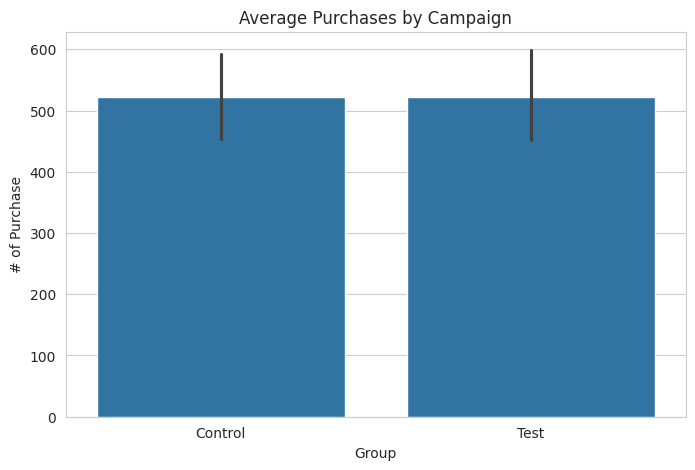

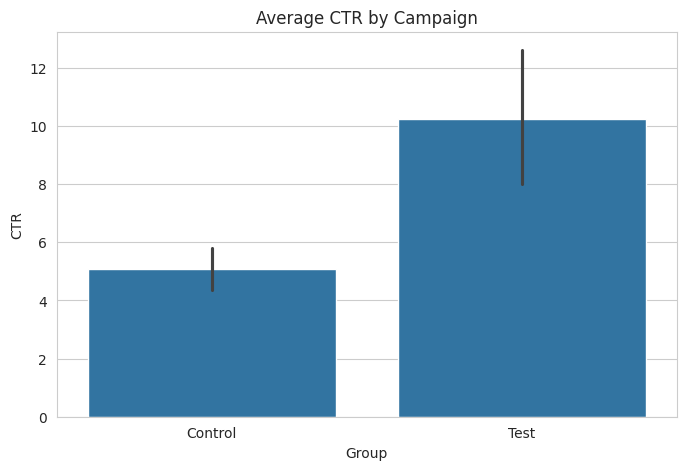

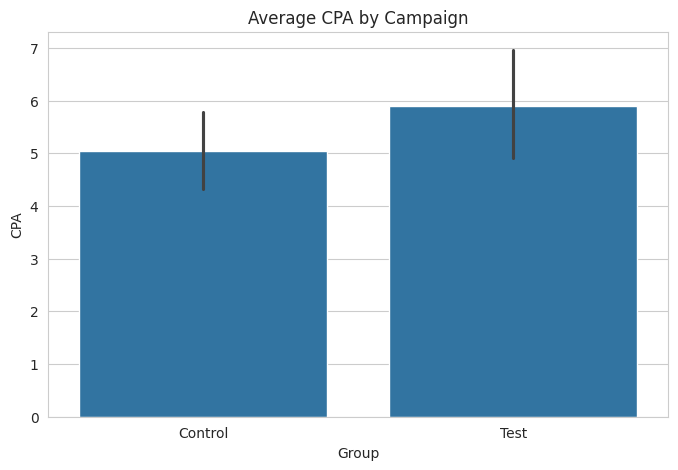

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=ab_data, x='Group', y='# of Purchase', estimator=np.mean)
plt.title('Average Purchases by Campaign')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=ab_data, x='Group', y='CTR', estimator=np.mean)
plt.title('Average CTR by Campaign')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=ab_data, x='Group', y='CPA', estimator=np.mean)
plt.title('Average CPA by Campaign')
plt.show()



# Daily Purchases Trend: Control vs Test

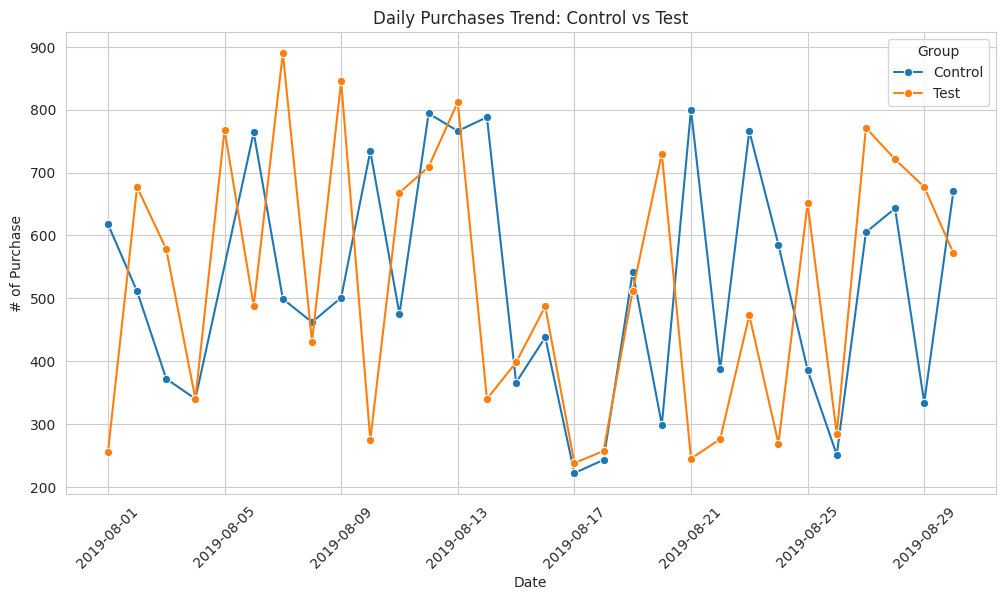

In [20]:
plt.figure(figsize=(12,6))
sns.lineplot(data=ab_data, x='Date', y='# of Purchase', hue='Group', marker='o')
plt.title('Daily Purchases Trend: Control vs Test')
plt.xticks(rotation=45)
plt.show()


# Correlation heatmap


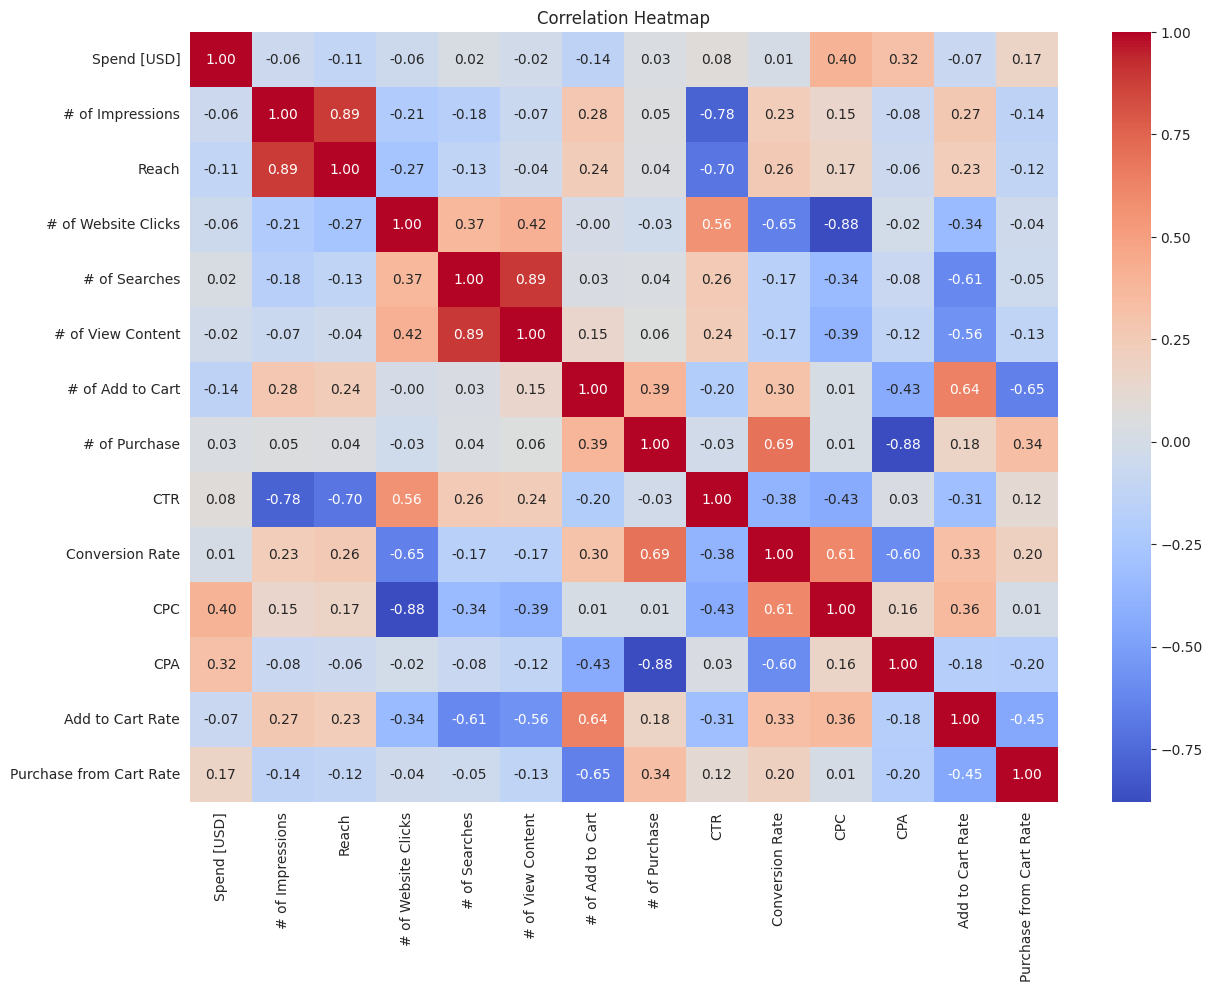

In [21]:
corr_data = ab_data.drop(columns=['Campaign Name', 'Date', 'Group'])
plt.figure(figsize=(14,10))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Statistical A/B Testing — Hypothesis Testing

## We use an Independent Sample T-Test to check whether the difference between the two campaigns is statistically significant.

# Hypothesis for Purchases
## Null Hypothesis (H₀)
## There is no significant difference in purchases between the Control and Test campaigns.
## H0: μcontrol is equal to μtest
# Alternative Hypothesis (H₁)
## There is a significant difference in purchases between the two campaigns.
## H1: μcontrol is not equal to μtest

# T-Test Code for Purchases

In [24]:
control_purchases = ab_data[ab_data['Group'] == 'Control']['# of Purchase']
test_purchases = ab_data[ab_data['Group'] == 'Test']['# of Purchase']

t_stat, p_value = ttest_ind(control_purchases, test_purchases, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.030212884995111548
P-value: 0.9760037958073526


In [26]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: Significant difference in purchases between Control and Test.")
else:
    print("Fail to reject the null hypothesis: No significant difference in purchases.")

Fail to reject the null hypothesis: No significant difference in purchases.


# Interpretation of Purchase Test

## Since:

## p=0.9760>0.05
## we fail to reject the null hypothesis.
# Conclusion
## There is no statistically significant difference in purchases between the Control and Test campaigns.
# Business meaning
## Although the Control campaign has slightly higher average purchases (522.79 vs 521.23), that difference is so small that it can easily be due to random variation.
## So from a purchase outcome perspective, the two campaigns are effectively performing the same.

# T-Test Code for other metrices

In [27]:
def ab_test_metric(data, metric):
    control = data[data['Group'] == 'Control'][metric]
    test = data[data['Group'] == 'Test'][metric]

    t_stat, p_value = ttest_ind(control, test, equal_var=False)

    print(f"\nMetric: {metric}")
    print("T-statistic:", round(t_stat, 4))
    print("P-value:", round(p_value, 4))

    if p_value < 0.05:
        print("Result: Significant difference between Control and Test")
    else:
        print("Result: No statistically significant difference")

In [28]:
metrics = [
    '# of Website Clicks',
    '# of Add to Cart',
    '# of Purchase',
    'CTR',
    'Conversion Rate'
]

for metric in metrics:
  ab_test_metric(ab_data, metric)



Metric: # of Website Clicks
T-statistic: -1.5761
P-value: 0.1205
Result: No statistically significant difference

Metric: # of Add to Cart
T-statistic: 4.2375
P-value: 0.0001
Result: Significant difference between Control and Test

Metric: # of Purchase
T-statistic: 0.0302
P-value: 0.976
Result: No statistically significant difference

Metric: CTR
T-statistic: -3.9786
P-value: 0.0003
Result: Significant difference between Control and Test

Metric: Conversion Rate
T-statistic: 1.49
P-value: 0.1428
Result: No statistically significant difference


# A) Website Clicks

### T-statistic = -1.5761
### P-value = 0.1205
## Interpretation
## Since 0.1205 > 0.05, the difference in clicks is not statistically significant.
## Insight
## Even though Test has more average clicks, we cannot say with statistical confidence that Test truly outperforms Control in clicks.
# B) Add to Cart
### T-statistic = 4.2375
### P-value = 0.0000869
## Interpretation
## Since p < 0.05, the difference is statistically significant.
## Insight
## The Control campaign’s higher Add-to-Cart performance is real and significant, not random.
## Business meaning
## Control genuinely performs better at pushing users from browsing into cart activity.
# C) Purchases
### T-statistic = 0.0302
### P-value = 0.9760
## Interpretation
## No significant difference.
# D) CTR
### T-statistic = -3.9786
### P-value = 0.0003388
## Interpretation
## Since p < 0.05, the difference in CTR is statistically significant.
## Insight
## The Test campaign’s higher CTR is real and meaningful.
## Business meaning
##Test is genuinely better at driving clicks from impressions.
# E) Conversion Rate
### T-statistic = 1.4900
### P-value = 0.1428
## Interpretation
## Since p > 0.05, the difference in conversion rate is not statistically significant.
## Business meaning
## Even though Control’s conversion rate looks better numerically, we do not have enough statistical evidence to say it is truly better.

# What the Test Campaign is Better At

# Test campaign strengths
## 1-Higher CTR (10.24% vs 5.10%)
### 2-More average website clicks
### 3-More searches
### 4-Slightly lower CPC
### 5-Higher purchase-from-cart rate
# Statistically significant advantage
### CTR is significantly higher in Test campaign
# Meaning
### The Test campaign is stronger at attracting user attention and generating engagement.

# What the Control Campaign is Better At

# Control campaign strengths
### 1-Higher impressions
### 2-Higher reach
### 3-Higher conversion rate
### 4-Higher Add-to-Cart volume
### 5-Lower CPA
### 6-Slightly more purchases
# Statistically significant advantage
### Add-to-Cart performance is significantly higher in Control campaign
## Meaning
### The Control campaign is better at driving users deeper into the purchase funnel and doing so at a lower acquisition cost.

# FINAL SUMMARY

In [29]:
final_summary = ab_data.groupby('Group')[[
    'Spend [USD]',
    '# of Impressions',
    'Reach',
    '# of Website Clicks',
    '# of Searches',
    '# of View Content',
    '# of Add to Cart',
    '# of Purchase',
    'CTR',
    'Conversion Rate',
    'CPC',
    'CPA'
]].mean().round(2)

print(final_summary)

         Spend [USD]  # of Impressions     Reach  # of Website Clicks  \
Group                                                                   
Control      2304.07         109559.76  88844.93              5320.79   
Test         2563.07          74584.80  53491.57              6032.33   

         # of Searches  # of View Content  # of Add to Cart  # of Purchase  \
Group                                                                        
Control        2221.31            1943.79           1300.00         522.79   
Test           2418.97            1858.00            881.53         521.23   

           CTR  Conversion Rate   CPC   CPA  
Group                                        
Control   5.10            11.48  0.49  5.05  
Test     10.24             9.23  0.47  5.90  


# The Most Important Business Finding

## Even though the Test campaign is much better at getting clicks, it does not translate into more purchases.
## That is the key takeaway of this project.
## In simple words:
### 1-Test campaign wins at engagement
### 2-Control campaign wins at shopping intent / purchase efficiency
### 3-Final purchases are basically the same

# Final Business Conclusion

# Final Conclusion
### The Test campaign significantly improves CTR, which means it is better at attracting users and generating clicks.
### However, the Control campaign performs better in lower-funnel metrics, especially Add-to-Cart rate and CPA, and it achieves almost the same number of purchases at a lower cost.
## Therefore:
### If the business goal is brand engagement / traffic / clicks, the Test campaign is better
### If the business goal is cost-efficient purchases and stronger funnel quality, the Control campaign is better

# Recommendation

# Recommended decision
## If the objective of the campaign is final sales / purchase efficiency, I would recommend continuing with the Control campaign or using the Control campaign as the base strategy.
## Why?
## Because:
### Purchases are statistically the same
### Control has lower CPA
### Control has higher Add-to-Cart performance
### Control seems to bring more purchase-intent traffic

# Strategic Recommendation for the Company

# The best practical business recommendation is:
### 1)Use a hybrid strategy
### 2)Use Test campaign creatives/messaging because they clearly improve CTR
### 3)Use Control campaign targeting or landing flow because it performs better in add-to-cart and cost efficiency
# This can create a stronger next version of the campaign:
### 1)Better engagement from Test
### 2)Better purchase funnel performance from Control